In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn 

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.9461000000238418 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                    

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv') 

In [4]:
df.shape

(212331, 15)

In [12]:
df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [39]:
df2=df[df['School DBN'].str.contains('M') & (df['Year'].isin([2016, 2017])) & (df['Regents Exam'] =='Common Core Algebra')]

In [40]:
df2.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,9,17.6,42,82.4,33,64.7,40,78.4
10,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2017,51,84.8,0,0,51,100,44,86.3,50,98


In [41]:
df2.shape

(4417, 15)

In [50]:
drop_cols = ['Number Scoring CR', 'Percent Scoring CR', 'Number Scoring Below 65', 'Number Scoring 65 or Above', 'Number Scoring 80 or Above']

In [51]:
df2.drop(drop_cols, inplace = True, axis=1)

In [52]:
df2.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Percent Scoring Below 65,Percent Scoring 65 or Above,Percent Scoring 80 or Above
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,17.6,82.4,64.7
10,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2017,51,84.8,0,100,86.3


In [65]:
cols = ['Percent Scoring Below 65', 'Percent Scoring 65 or Above', 'Percent Scoring 80 or Above', 'Mean Score']

In [66]:
for col in cols: df2[col] = df2[col].astype(str).str.replace('s', "")

In [67]:
df2.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Percent Scoring Below 65,Percent Scoring 65 or Above,Percent Scoring 80 or Above
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,,,,
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,,,,
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,,,,
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,17.6,82.4,64.7
10,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2017,51,84.8,0,100,86.3


In [74]:
cols = ['Mean Score', 'Percent Scoring Below 65', 'Percent Scoring 65 or Above', 'Percent Scoring 80 or Above']

In [75]:
df2 = df2.dropna(subset=cols)

In [76]:
df2.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Percent Scoring Below 65,Percent Scoring 65 or Above,Percent Scoring 80 or Above
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,,,,
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,,,,
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,,,,
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,17.6,82.4,64.7
10,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2017,51,84.8,0,100,86.3


In [77]:
last4 = df2.columns[-4:]

In [79]:
df2 = df2.dropna(subset=last4)

In [89]:
df2.tail()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Percent Scoring Below 65,Percent Scoring 65 or Above,Percent Scoring 80 or Above
210225,84M726,KIPP STAR College Prep Charter School,K-12 all grades,Common Core Algebra,2016,3,,,,
210226,84M726,KIPP STAR College Prep Charter School,K-12 all grades,Common Core Algebra,2016,1,,,,
210227,84M726,KIPP STAR College Prep Charter School,K-12 all grades,Common Core Algebra,2017,41,,,,
210228,84M726,KIPP STAR College Prep Charter School,K-12 all grades,Common Core Algebra,2017,47,74.9,12.8,87.2,38.3
210229,84M726,KIPP STAR College Prep Charter School,K-12 all grades,Common Core Algebra,2017,2,,,,


In [103]:
df2_compare = df2[df2["Year"].isin([2016,2017])]

In [104]:
df2_compare["Mean Score"] = pd.to_numeric(df2_compare['Mean Score'], errors='coerce')

In [107]:
print(df2_compare.groupby("Year")['Mean Score'].mean())

Year
2016    69.824965
2017    71.009363
Name: Mean Score, dtype: float64


<Axes: xlabel='Year'>

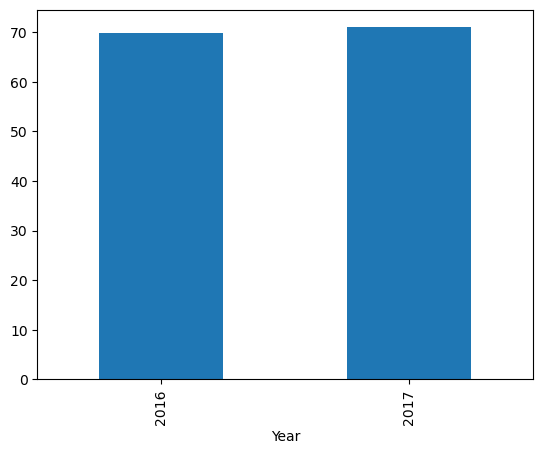

In [111]:
df2_compare.groupby("Year")['Mean Score'].mean().plot(kind='bar')

I chose to compare common core algebra scores across borough of manhattan schools for 2016 vs 2017. The data shows that the mean score was better in 2017 vs that of 2016 which leads me to conclude that the board of ed worked to improve their test scores from 2016 to 2017 to ensure their average was above 70
